In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, linalg

 - https://math.stackexchange.com/questions/316849/intersection-of-conics-using-matrix-representation
 - https://en.wikipedia.org/wiki/Conic_section
 - https://math.stackexchange.com/questions/328300/decomposition-of-a-degenerate-conic
 - https://arxiv.org/html/2403.08953v1
 - https://scicomp.stackexchange.com/questions/26938/matrix-decomposition-of-conics
 - https://math.stackexchange.com/questions/2381179/decomposition-of-conic-equation-for-two-intersecting-lines

Pencil of conics:

$$
C_\lambda = C_0 + \lambda C_1
$$

Then:

$$
\det (C_\lambda) = 0 = \det (\lambda I - A), A = C_0 (- C_1)^{-1}
$$


In [2]:
C0 = np.array([
    [3, 1, 1],
    [1, -2, 1],
    [1, 1, -1],
])

In [3]:
C1 = np.array([
    [-3, 1, 1],
    [1, -2, 1],
    [1, 1, 10],
])

In [4]:
n = 200
x0lin = np.linspace(-10, 10, n)
x1lin = np.linspace(-10, 10, n)
X0, X1 = np.meshgrid(x0lin, x1lin)

In [5]:
A = C0 @ np.linalg.inv(- C1)

In [6]:
A

array([[ 1.21052632e+00,  9.47368421e-01, -3.15789474e-01],
       [ 5.55111512e-17, -1.00000000e+00,  0.00000000e+00],
       [ 5.78947368e-01,  7.71929825e-01, -3.50877193e-02]])

In [7]:
l, V = np.linalg.eig(A)

In [8]:
l

array([ 1.04055823,  0.13488037, -1.        ])

In [9]:
M0 = C0 + l[0] * C1

In [10]:
M1 = C0 + l[1] * C1

In [11]:
M2 = C0 + l[2] * C1

In [12]:
np.linalg.det(M0[:2,:2])

-3.6673093263711833

In [13]:
np.linalg.det(M1[:2,:2])

-7.178797167934753

In [14]:
np.linalg.det(M2[:2,:2])

2.664535259100367e-15

In [15]:
x = np.array([
    X0.ravel(),
    X1.ravel(),
    np.ones(X0.size)
]).T

In [16]:
g0 = np.apply_along_axis(lambda z: z @ C0 @ z.T, axis=1, arr=x)
G0 = g0.reshape(X0.shape)

In [17]:
g1 = np.apply_along_axis(lambda z: z @ C1 @ z.T, axis=1, arr=x)
G1 = g1.reshape(X0.shape)

In [18]:
d0 = np.apply_along_axis(lambda z: z @ M0 @ z.T, axis=1, arr=x)
D0 = d0.reshape(X0.shape)

In [19]:
d1 = np.apply_along_axis(lambda z: z @ M1 @ z.T, axis=1, arr=x)
D1 = d1.reshape(X0.shape)

In [20]:
d2 = np.apply_along_axis(lambda z: z @ M2 @ z.T, axis=1, arr=x)
D2 = d2.reshape(X0.shape)

In [21]:
U0, s0, Vh0 = np.linalg.svd(M0)
U0, s0, Vh0

(array([[ 0.22238405,  0.35319291,  0.90873544],
        [ 0.16855613, -0.93196813,  0.32097388],
        [ 0.96027817,  0.08179346, -0.26678768]]),
 array([1.02363168e+01, 5.03352564e+00, 4.83631819e-16]),
 array([[ 0.22238405,  0.16855613,  0.96027817],
        [-0.35319291,  0.93196813, -0.08179346],
        [-0.90873544, -0.32097388,  0.26678768]]))

In [22]:
U1, s1, Vh1 = np.linalg.svd(M1)
U1, s1, Vh1

(array([[-0.874812  ,  0.13783167, -0.46444203],
        [-0.25485668, -0.9462322 ,  0.19923028],
        [-0.41200976,  0.2926552 ,  0.8629026 ]]),
 array([3.46047464e+00, 2.78607279e+00, 4.64431392e-16]),
 array([[-0.874812  , -0.25485668, -0.41200976],
        [-0.13783167,  0.9462322 , -0.2926552 ],
        [ 0.46444203, -0.19923028, -0.8629026 ]]))

In [23]:
U2, s2, Vh2 = np.linalg.svd(M2)
U2, s2, Vh2

(array([[-3.70074342e-17, -1.00000000e+00, -3.70074342e-17],
        [-1.11022302e-16,  3.70074342e-17, -1.00000000e+00],
        [-1.00000000e+00,  3.70074342e-17,  2.22044605e-16]]),
 array([1.10000000e+01, 6.00000000e+00, 1.20122491e-15]),
 array([[ 0.00000000e+00, -1.01311409e-16,  1.00000000e+00],
        [-1.00000000e+00, -0.00000000e+00,  0.00000000e+00],
        [-0.00000000e+00, -1.00000000e+00,  0.00000000e+00]]))

In [24]:
B0 = np.conj(M0).T
B0

array([[-0.12167468,  2.04055823,  2.04055823],
       [ 2.04055823, -4.08111646,  2.04055823],
       [ 2.04055823,  2.04055823,  9.40558228]])

In [25]:
B0[:,0] / np.sqrt(B0[1, 0])

array([-0.08517767,  1.42848109,  1.42848109])

In [26]:
np.linalg.matrix_rank(M1)

2

In [27]:
linalg.eig(M0)

(array([ 1.02363168e+01+0.j, -2.70643967e-16+0.j, -5.03352564e+00+0.j]),
 array([[-0.22238405, -0.90873544,  0.35319291],
        [-0.16855613, -0.32097388, -0.93196813],
        [-0.96027817,  0.26678768,  0.08179346]]))

In [48]:
x0 = linalg.null_space(M0)
x0 /= x0[2,0]
x0

array([[-3.40621217],
       [-1.20310608],
       [ 1.        ]])

In [47]:
x1 = linalg.null_space(M1)
x1 /= x1[2,0]
x1

array([[-0.53823228],
       [ 0.23088386],
       [ 1.        ]])

In [31]:
x2 = linalg.null_space(M2)
x2

array([[-0.],
       [-1.],
       [ 0.]])

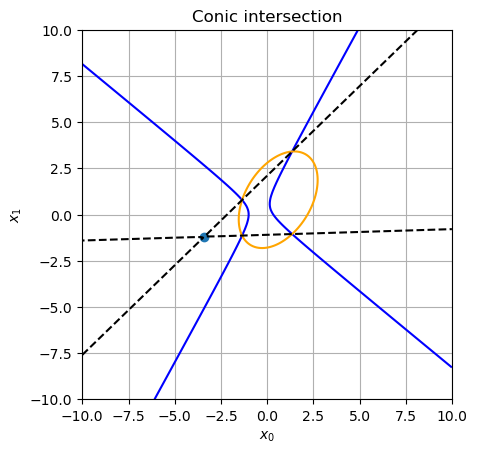

In [57]:
fig, axe = plt.subplots()
axe.contour(X0, X1, G0, levels=[0], colors="blue")
axe.contour(X0, X1, G1, levels=[0], colors="orange")
axe.contour(X0, X1, D0, levels=[0], colors="black", linestyles="--")
axe.scatter(*x0[:2,0])
#axe.arrow(*x0[:2,0], *U0[:,1])
axe.set_title("Conic intersection")
axe.set_xlabel("$x_0$")
axe.set_ylabel("$x_1$")
axe.set_aspect("equal")
axe.grid()

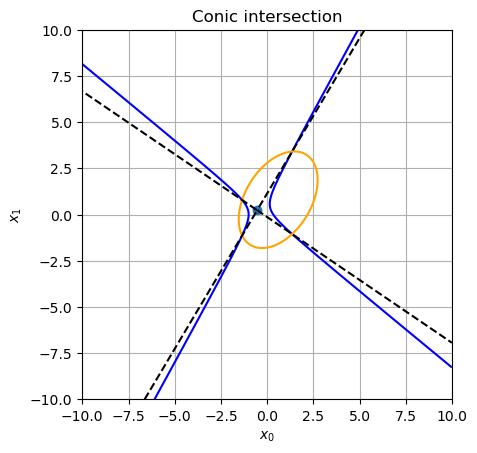

In [46]:
fig, axe = plt.subplots()
axe.contour(X0, X1, G0, levels=[0], colors="blue")
axe.contour(X0, X1, G1, levels=[0], colors="orange")
axe.contour(X0, X1, D1, levels=[0], colors="black", linestyles="--")
axe.scatter(*x1[:2,0])
axe.set_title("Conic intersection")
axe.set_xlabel("$x_0$")
axe.set_ylabel("$x_1$")
axe.set_aspect("equal")
axe.grid()

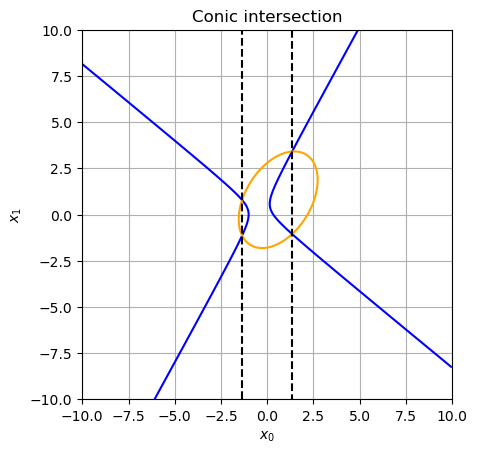

In [34]:
fig, axe = plt.subplots()
axe.contour(X0, X1, G0, levels=[0], colors="blue")
axe.contour(X0, X1, G1, levels=[0], colors="orange")
axe.contour(X0, X1, D2, levels=[0], colors="black", linestyles="--")
axe.set_title("Conic intersection")
axe.set_xlabel("$x_0$")
axe.set_ylabel("$x_1$")
axe.set_aspect("equal")
axe.grid()